# CNN Baseline - SVHN Digit Classification

This is a  CNN base model - built with the Keras Functional API. 

Uses the same `load_image_data()` split as the DNN notebook - same train,
val, and test sets, same evaluation code - so the comparison between the
two is a fair one, not just two different experiments that happen to share
a dataset.

In [1]:
import graphviz
import pydot
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers

from data_util import load_image_data
from eval_util import get_predicted_labels, per_class_accuracy, get_confusion_matrix, get_classification_report
from visualisation_util import plot_training_curves, plot_confusion_matrix, sample_prediction_grid

In [2]:
(x_train, y_train), (x_val, y_val), (x_test, y_test) = load_image_data()

print("train:", x_train.shape, y_train.shape)
print("val:  ", x_val.shape, y_val.shape)
print("test: ", x_test.shape, y_test.shape)
print("label range:", y_train.min(), "to", y_train.max())

train: (65932, 32, 32, 3) (65932,)
val:   (7325, 32, 32, 3) (7325,)
test:  (26032, 32, 32, 3) (26032,)
label range: 0 to 9


In [3]:
def conv_block(x, filters):
    x = layers.Conv2D(filters, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D(2)(x)
    return x


def residual_block(x, filters):
    shortcut = x
    y = layers.Conv2D(filters, 3, padding="same")(x)
    y = layers.BatchNormalization()(y)
    y = layers.ReLU()(y)
    y = layers.Conv2D(filters, 3, padding="same")(y)
    y = layers.BatchNormalization()(y)

    # shortcut needs to match y's channel count before they can be added
    if shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, 1, padding="same")(shortcut)

    out = layers.Add()([shortcut, y])
    out = layers.ReLU()(out)
    return out


inputs = keras.Input(shape=(32, 32, 3))

x = conv_block(inputs, 32)
x = conv_block(x, 64)
x = residual_block(x, 64)
x = conv_block(x, 128)

x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(10, activation="softmax")(x)

model = keras.Model(inputs=inputs, outputs=outputs)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 32, 32,    │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 32, 32,    │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 32, 32,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 16, 16,    │          0 │ re_lu[0][0]       │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 16, 16,    │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 16, 16,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 8, 8, 64)  │          0 │ re_lu_1[0][0]     │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 8, 8, 64)  │     36,928 │ max_pooling2d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 8, 8, 64)  │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 8, 8, 64)  │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 8, 8, 64)  │     36,928 │ re_lu_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 8, 8, 64)  │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 8, 8, 64)  │          0 │ max_pooling2d_1[… │
│                     │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 8, 8, 64)  │          0 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 8, 8, 128) │     73,856 │ re_lu_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 8, 8, 128) │        512 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 169,802 (663.29 KB)

 Trainable params: 169,098 (660.54 KB)

 Non-trainable params: 704 (2.75 KB)

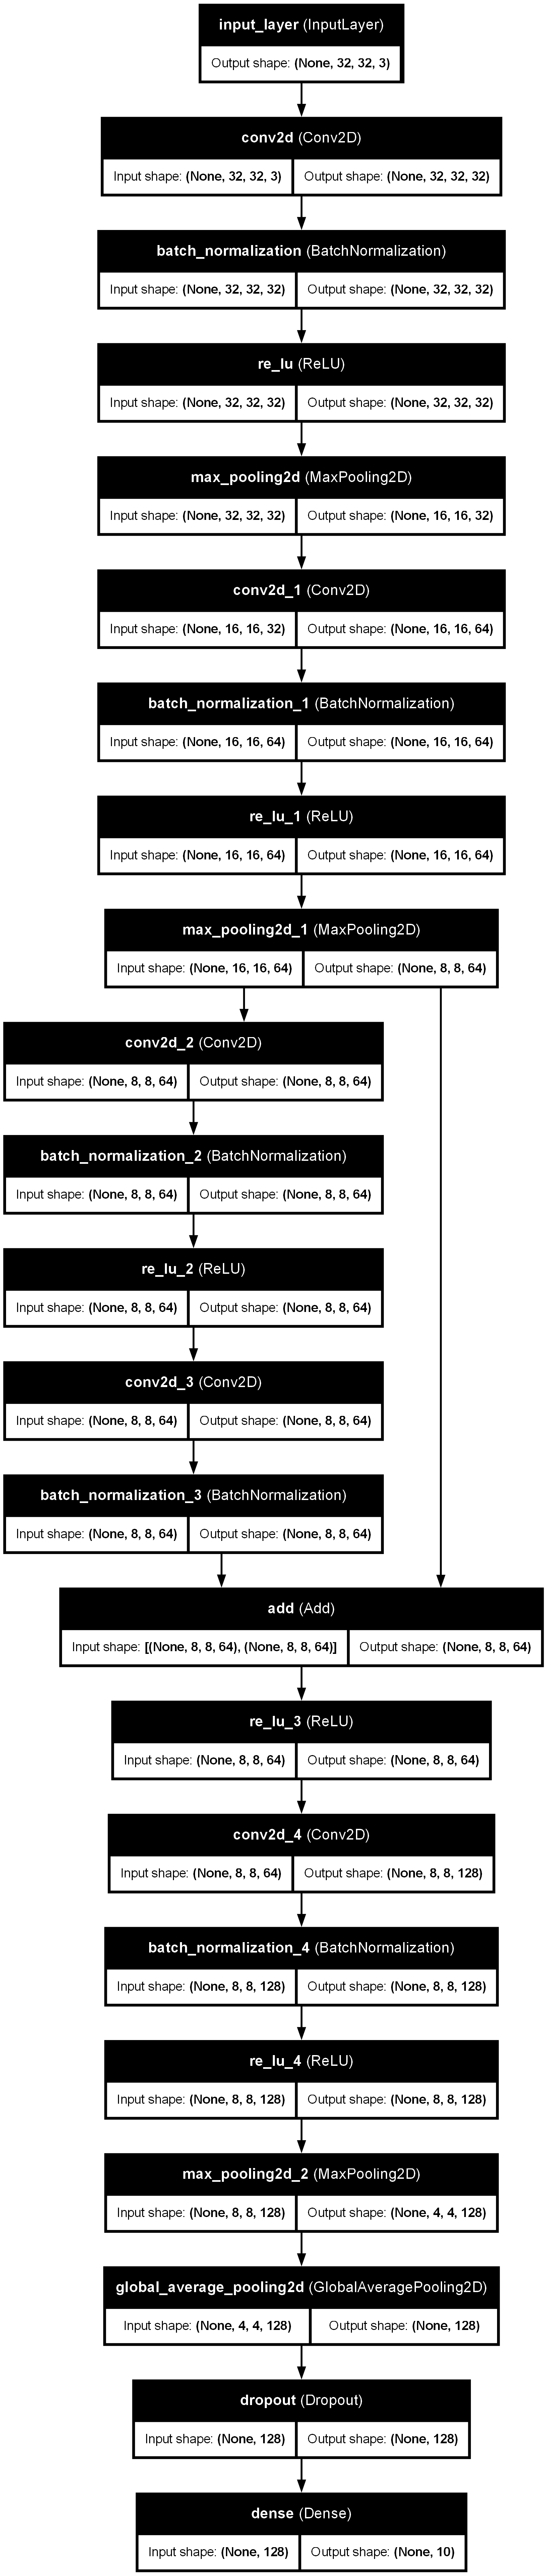

In [4]:
keras.utils.plot_model(model, to_file="images/cnn_architecture.png", show_shapes=True, show_layer_names=True)

In [5]:
history = model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=20,
    batch_size=128,
    callbacks=[keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)],
)

Epoch 1/20
516/516 ━━━━━━━━━━━━━━━━━━━━ 147s 235ms/step - accuracy: 0.2544 - loss: 2.1827 - val_accuracy: 0.3162 - val_loss: 2.0518
Epoch 2/20
516/516 ━━━━━━━━━━━━━━━━━━━━ 87s 168ms/step - accuracy: 0.4664 - loss: 1.5612 - val_accuracy: 0.5629 - val_loss: 1.3410
Epoch 3/20
516/516 ━━━━━━━━━━━━━━━━━━━━ 83s 161ms/step - accuracy: 0.6284 - loss: 1.1292 - val_accuracy: 0.7088 - val_loss: 0.9129
Epoch 4/20
516/516 ━━━━━━━━━━━━━━━━━━━━ 88s 171ms/step - accuracy: 0.7268 - loss: 0.8634 - val_accuracy: 0.7592 - val_loss: 0.7695
Epoch 5/20
516/516 ━━━━━━━━━━━━━━━━━━━━ 73s 142ms/step - accuracy: 0.7779 - loss: 0.7144 - val_accuracy: 0.8198 - val_loss: 0.6038
Epoch 6/20
516/516 ━━━━━━━━━━━━━━━━━━━━ 64s 124ms/step - accuracy: 0.8083 - loss: 0.6230 - val_accuracy: 0.8277 - val_loss: 0.5828
Epoch 7/20
516/516 ━━━━━━━━━━━━━━━━━━━━ 149s 288ms/step - accuracy: 0.8305 - loss: 0.5534 - val_accuracy: 0.8177 - val_loss: 0.5865
Epoch 8/20
516/516 ━━━━━━━━━━━━━━━━━━━━ 92s 177ms/step - accuracy: 0.8452 - loss:

## EValuation

In [6]:
y_pred = get_predicted_labels(model, x_test)

test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)
print(f"Test accuracy: {test_accuracy:.4f}")

Test accuracy: 0.9083


In [7]:
acc_by_class = per_class_accuracy(y_test, y_pred)
for label, acc in acc_by_class.items():
    print(f"digit {label}: {acc:.3f}")

digit 0: 0.905
digit 1: 0.921
digit 2: 0.926
digit 3: 0.878
digit 4: 0.964
digit 5: 0.890
digit 6: 0.901
digit 7: 0.940
digit 8: 0.801
digit 9: 0.900


In [8]:
print(get_classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.90      0.91      1744
           1       0.96      0.92      0.94      5099
           2       0.97      0.93      0.95      4149
           3       0.89      0.88      0.88      2882
           4       0.84      0.96      0.90      2523
           5       0.93      0.89      0.91      2384
           6       0.85      0.90      0.88      1977
           7       0.89      0.94      0.92      2019
           8       0.89      0.80      0.84      1660
           9       0.84      0.90      0.87      1595

    accuracy                           0.91     26032
   macro avg       0.90      0.90      0.90     26032
weighted avg       0.91      0.91      0.91     26032



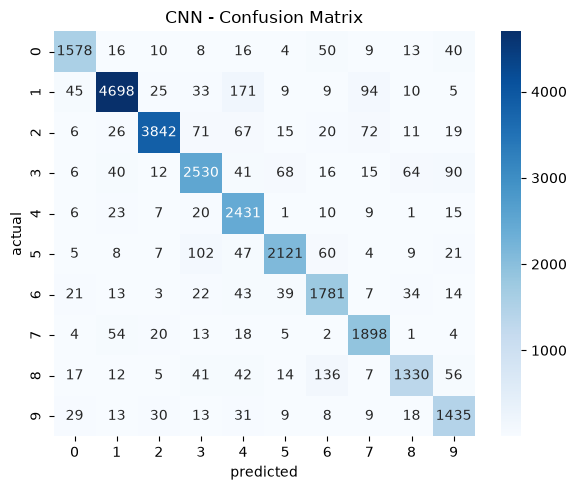

In [9]:
cm = get_confusion_matrix(y_test, y_pred)
fig = plot_confusion_matrix(cm, title="CNN - Confusion Matrix")
fig.savefig("images/cnn_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()


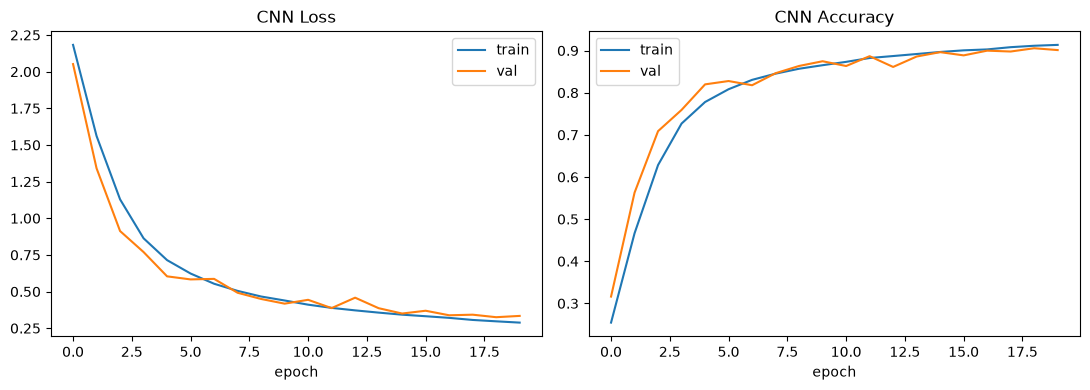

In [10]:
fig = plot_training_curves(history, title="CNN")
fig.savefig("images/cnn_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

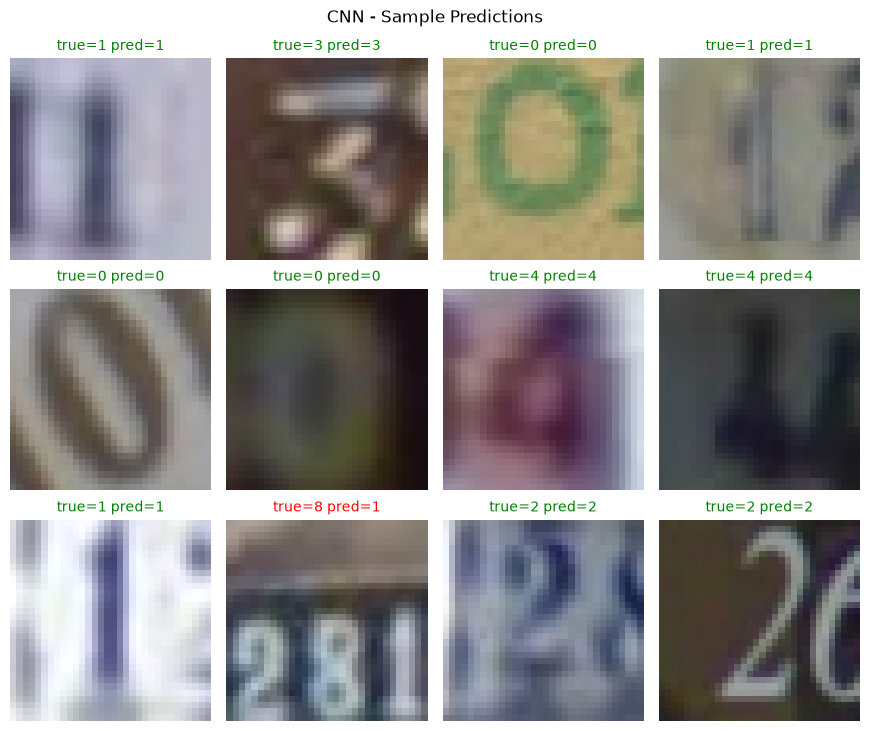

In [11]:
fig = sample_prediction_grid(x_test, y_test, y_pred, title="CNN - Sample Predictions")
fig.savefig("images/cnn_sample_predictions.png", dpi=150, bbox_inches="tight")
plt.show()
